In [1]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns
import ipywidgets as widgets
from IPython.display import display

import warnings
warnings.filterwarnings("ignore")

plt.rcParams['figure.figsize'] = (12, 6)
sns.set_theme(style="whitegrid")
pd.set_option('display.max_columns', None)

In [2]:
df_exposure = pd.read_csv("Data/exposure_and_game_info/exposure_results_2025_26.csv")
df_metadata = pd.read_csv("Data/urls/game_highlight_urls_2025_26.csv")
df_game_info = pd.read_csv("Data/exposure_and_game_info/nba_games_2025-26.csv")

df = pd.merge(df_exposure, df_metadata.drop(columns=['game_id', 'title', 'url']), on="video_id", how='left')
df = pd.merge(df, df_game_info[['GAME_ID', 'HOME_TEAM_ID', "HOME_TEAM_NAME", 'AWAY_TEAM_ID', "AWAY_TEAM_NAME", 'GAME_DATE']], left_on='game_id', right_on='GAME_ID', how='left')

display(df.head())
print(df.shape)

,game_id,video_id,exposure_zone,exposure_seconds,total_detections,total_media_value,qi_score_avg,qi_score_std,size_score_avg,size_score_std,sov_weighted_avg,sov_weighted_std,dist_score_avg,dist_score_std,legi_score_avg,legi_score_std,conf_avg,conf_std,laplacian_avg,laplacian_std,dist_raw_pct_avg,dist_raw_pct_std,area_pct_avg,area_pct_std,video_url,channel,duration,view_count,like_count,comment_count,GAME_ID,HOME_TEAM_ID,HOME_TEAM_NAME,AWAY_TEAM_ID,AWAY_TEAM_NAME,GAME_DATE
0,22500424,l5ir1TZxJjk,back-court-logo,441.84,2207,902.6944,0.2449,0.1704,0.4781,0.0577,0.9302,0.0246,0.5455,0.3689,1.0000,0.0000,0.8819,0.0268,986.16,200.03,24.47,18.09,1.411,0.236,https://www.youtube.com/watch?v=l5ir1TZxJjk,GAMETIME HIGHLIGHTS,576,25306,347,31.0,22500424,1610612753,Orlando Magic,1610612766,Charlotte Hornets,2025-12-26
1,22500424,l5ir1TZxJjk,basket-logo,416.02,9418,521.3464,0.0331,0.0329,0.1919,0.0743,0.4515,0.1200,0.3863,0.3093,0.9971,0.0398,0.9017,0.0472,2833.79,2223.84,32.92,18.02,0.214,0.106,https://www.youtube.com/watch?v=l5ir1TZxJjk,GAMETIME HIGHLIGHTS,576,25306,347,31.0,22500424,1610612753,Orlando Magic,1610612766,Charlotte Hornets,2025-12-26
2,22500424,l5ir1TZxJjk,mid-court-logo,410.21,2225,858.9312,0.2311,0.2137,0.6212,0.2562,0.8860,0.1172,0.3841,0.3083,1.0000,0.0000,0.8755,0.0590,1390.13,379.95,31.07,15.05,2.244,1.475,https://www.youtube.com/watch?v=l5ir1TZxJjk,GAMETIME HIGHLIGHTS,576,25306,347,31.0,22500424,1610612753,Orlando Magic,1610612766,Charlotte Hornets,2025-12-26
3,22500424,l5ir1TZxJjk,side-court-logo,484.48,2508,597.2365,0.1426,0.0926,0.3494,0.0547,0.8884,0.0773,0.4650,0.2982,0.9970,0.0528,0.8934,0.0210,1767.25,343.13,26.25,12.69,0.961,1.517,https://www.youtube.com/watch?v=l5ir1TZxJjk,GAMETIME HIGHLIGHTS,576,25306,347,31.0,22500424,1610612753,Orlando Magic,1610612766,Charlotte Hornets,2025-12-26
4,22500424,l5ir1TZxJjk,side-court-led-logo,293.69,1467,483.1845,0.1972,0.2136,0.4417,0.2574,0.7917,0.2026,0.4341,0.3027,0.9703,0.1528,0.8894,0.0595,717.40,400.66,29.01,15.31,2.153,7.290,https://www.youtube.com/watch?v=l5ir1TZxJjk,GAMETIME HIGHLIGHTS,576,25306,347,31.0,22500424,1610612753,Orlando Magic,1610612766,Charlotte Hornets,2025-12-26


(8250, 36)


          GENERAL STATISTICS

Global
  Total Value      : $  14,607,335.72
  Total Videos     :           1,649
  Total Games      :             522

AVERAGES PER GAME
  Value/video       : $       8,858.30
  Value/game       : $      27,983.40

DAILY AVERAGES
  Games/day        :            6.87
  Value/day        : $     192,201.79
  Analysis Period  :              76 days


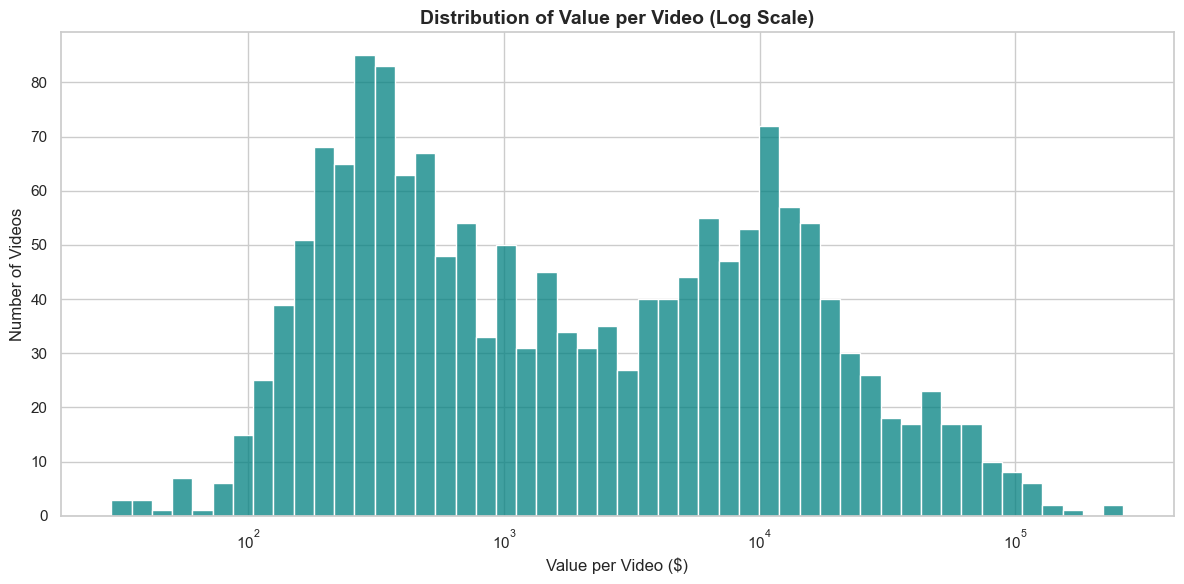

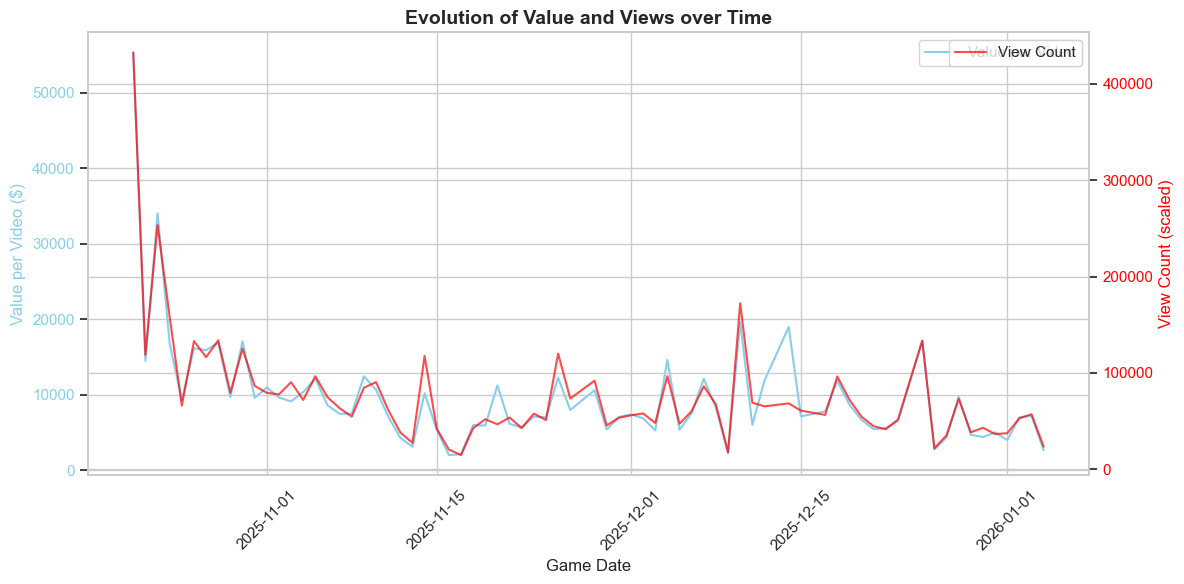

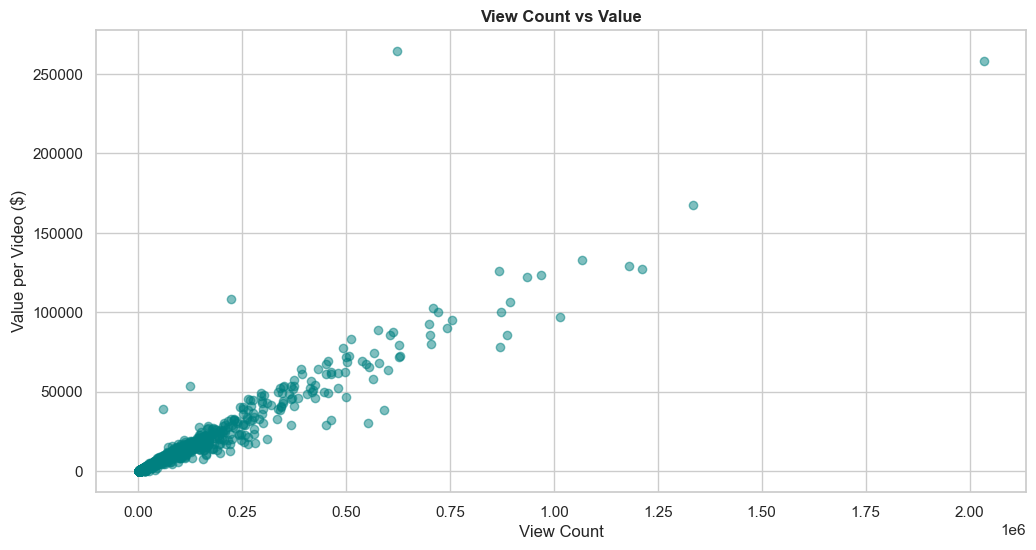


          TOP 10 MOST VALUED GAMES


,value_per_game,HOME_TEAM_NAME,AWAY_TEAM_NAME
6866,309156.9111,Los Angeles Lakers,Golden State Warriors
6531,255392.7104,Golden State Warriors,Memphis Grizzlies
2285,219338.6065,Los Angeles Lakers,Phoenix Suns
6886,217401.4063,Golden State Warriors,Denver Nuggets
4995,209633.2874,Los Angeles Lakers,San Antonio Spurs
6741,180901.7170,Los Angeles Lakers,Minnesota Timberwolves
5967,176534.2752,Memphis Grizzlies,Los Angeles Lakers
1332,173999.2027,Phoenix Suns,Los Angeles Lakers
6341,170463.4697,Golden State Warriors,LA Clippers
2693,163710.9462,Los Angeles Lakers,Dallas Mavericks


In [3]:
# =============================================================================
# DATA PREPARATION
# =============================================================================

# Convert game date to datetime format
df['GAME_DATE'] = pd.to_datetime(df['GAME_DATE'])

# Aggregate value per video
value_per_video = df.groupby('video_id')["total_media_value"].sum()
df['value_per_video'] = df['video_id'].map(value_per_video)

# Aggregate value per game
value_per_game = df.groupby('game_id')['total_media_value'].sum()
df['value_per_game'] = df['game_id'].map(value_per_game)

# Create deduplicated video dataset
df_videos = df.drop_duplicates(subset='video_id')
df_games = df.drop_duplicates(subset='game_id')

# Calculate key metrics
total_value = df['total_media_value'].sum()
nb_games = df_videos['game_id'].nunique()
nb_videos = df_videos['video_id'].nunique()
total_days = (df_videos['GAME_DATE'].max() - df_videos['GAME_DATE'].min()).days + 1

# =============================================================================
# GENERAL STATISTICS
# =============================================================================

print("=" * 50)
print("          GENERAL STATISTICS")
print("=" * 50)

print("\nGlobal")
print(f"  Total Value      : ${total_value:>15,.2f}")
print(f"  Total Videos     : {nb_videos:>15,}")
print(f"  Total Games      : {nb_games:>15,}")

print("\nAVERAGES PER GAME")
print(f"  Value/video       : ${total_value/nb_videos:>15,.2f}")
print(f"  Value/game       : ${total_value/nb_games:>15,.2f}")

print("\nDAILY AVERAGES")
print(f"  Games/day        : {nb_games / total_days:>15.2f}")
print(f"  Value/day        : ${total_value/total_days:>15,.2f}")
print(f"  Analysis Period  : {total_days:>15} days")
print("=" * 50)

# =============================================================================
# VISUALIZATIONS
# =============================================================================

# 1. Distribution of value per video (Logarithmic scale)
plt.figure(figsize=(12, 6))
sns.histplot(df_videos['value_per_video'], bins=50, log_scale=True, color='teal')
plt.title("Distribution of Value per Video (Log Scale)", fontsize=14, fontweight='bold')
plt.xlabel("Value per Video ($)")
plt.ylabel("Number of Videos")
plt.tight_layout()
plt.show()

# 2. Temporal evolution of value and views
fig, ax1 = plt.subplots(figsize=(12, 6))

# Plot value per video
color = 'skyblue'
ax1.set_xlabel('Game Date', fontsize=12)
ax1.set_ylabel('Value per Video ($)', color=color, fontsize=12)
sns.lineplot(x=df_videos['GAME_DATE'], y=df_videos['value_per_video'], 
             color=color, ax=ax1, label='Value per Video', errorbar=None)
ax1.tick_params(axis='y', labelcolor=color)
ax1.tick_params(axis='x', rotation=45)

# Create second y-axis for view count
ax2 = ax1.twinx()
color = 'red'
ax2.set_ylabel('View Count (scaled)', color=color, fontsize=12)
sns.lineplot(x=df_videos['GAME_DATE'], y=df_videos['view_count'], 
             color=color, ax=ax2, label='View Count', alpha=0.7, errorbar=None)
ax2.tick_params(axis='y', labelcolor=color)

plt.title("Evolution of Value and Views over Time", fontsize=14, fontweight='bold')
fig.tight_layout()
plt.show()

# 3. Correlation between metrics
plt.figure(figsize=(12, 6))
plt.scatter(df_videos['view_count'], df_videos['value_per_video'], 
            alpha=0.5, color='teal')
plt.xlabel('View Count')
plt.ylabel('Value per Video ($)')
plt.title('View Count vs Value', fontweight='bold')
plt.show()

# =============================================================================
# TOP GAMES
# =============================================================================

print("\n" + "=" * 50)
print("          TOP 10 MOST VALUED GAMES")
print("=" * 50)

display(df_games[['value_per_game', 'HOME_TEAM_NAME', 'AWAY_TEAM_NAME']].sort_values(by='value_per_game', ascending=False).head(10))


          VALUE CREATED BY EACH TEAM WITH POPULATION PERSPECTIVE

All 30 NBA Teams:



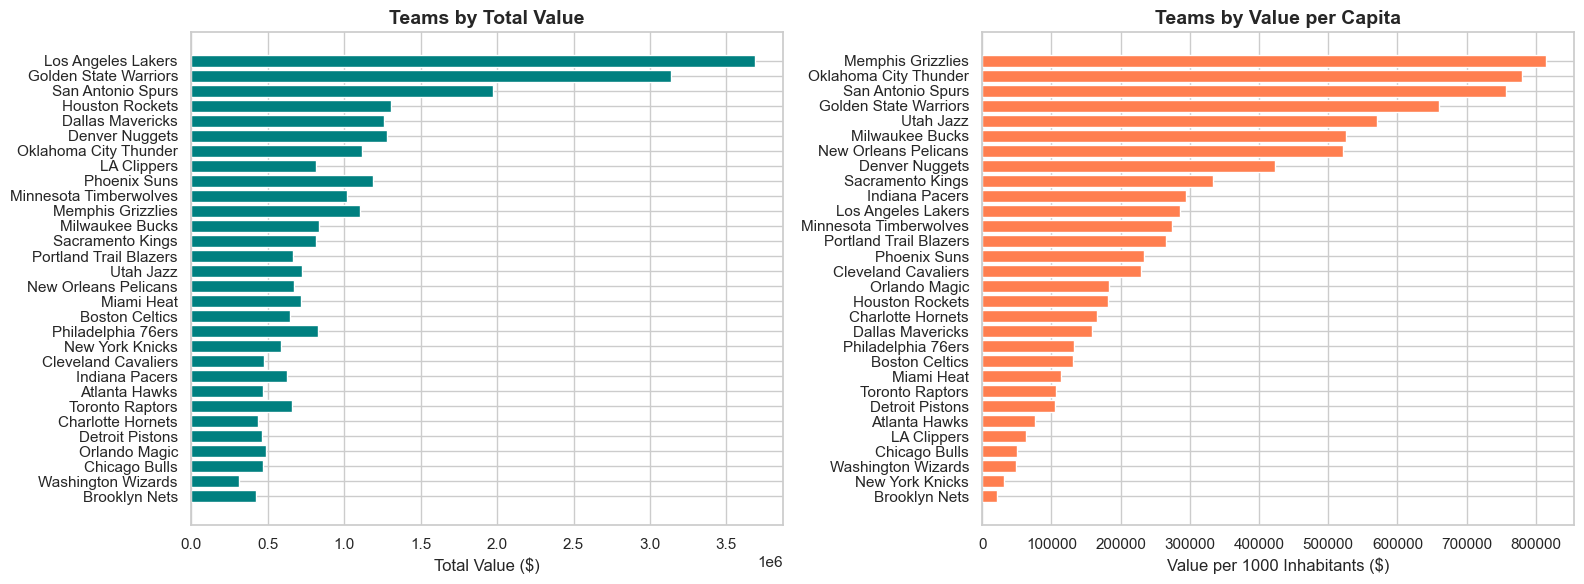

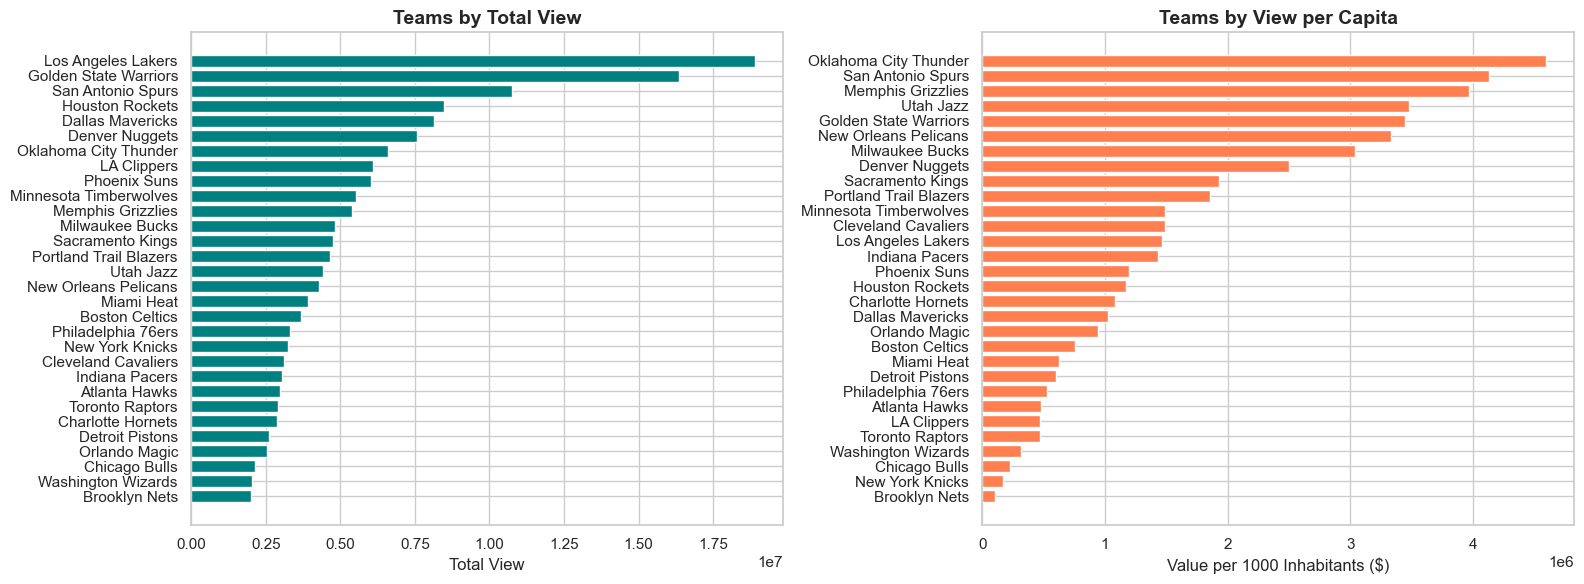

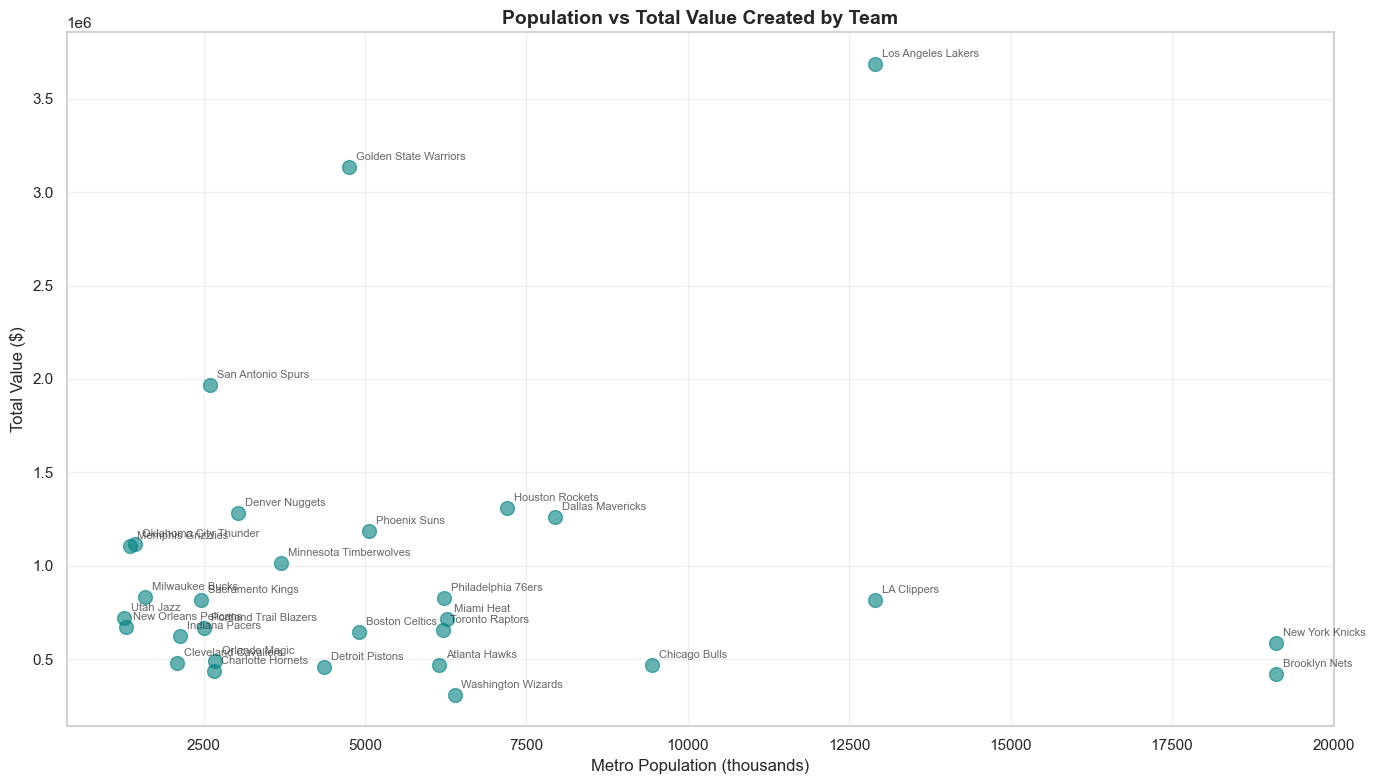


          SUMMARY STATISTICS

Value per Capita Statistics:
  Mean   : $  284,700.28 per 1000 inhabitants
  Median : $  206,323.36 per 1000 inhabitants
  Min    : $   22,089.52 per 1000 inhabitants
  Max    : $  814,321.49 per 1000 inhabitants


In [4]:
# =============================================================================
# VALUE BY TEAM WITH POPULATION PERSPECTIVE
# =============================================================================

# Create a dataframe for home teams
home_value = df_games.groupby('HOME_TEAM_NAME').agg({
    'value_per_game': 'sum',
    'view_count': 'sum',
    'game_id': 'count'
}).rename(columns={
    'value_per_game': 'total_value',
    'view_count': 'total_view',
    'game_id': 'nb_games'
})

# Create a dataframe for away teams
away_value = df_games.groupby('AWAY_TEAM_NAME').agg({
    'value_per_game': 'sum',
    'view_count': 'sum',
    'game_id': 'count'
}).rename(columns={
    'value_per_game': 'total_value',
    'view_count': 'total_view',
    'game_id': 'nb_games'
})

# Combine both (sum values for each team)
team_value = home_value.add(away_value, fill_value=0)

# Population data (in thousands) from 2024 metro areas
population_data = {
    'Atlanta Hawks': 6144,
    'Boston Celtics': 4899,
    'Brooklyn Nets': 19113,
    'Charlotte Hornets': 2660,
    'Chicago Bulls': 9441,
    'Cleveland Cavaliers': 2088,
    'Dallas Mavericks': 7943,
    'Denver Nuggets': 3038,
    'Detroit Pistons': 4365,
    'Golden State Warriors': 4749,
    'Houston Rockets': 7206,
    'Indiana Pacers': 2126,
    'LA Clippers': 12901,
    'Los Angeles Lakers': 12901,
    'Memphis Grizzlies': 1358,
    'Miami Heat': 6266,
    'Milwaukee Bucks': 1586,
    'Minnesota Timberwolves': 3703,
    'New Orleans Pelicans': 1290,
    'New York Knicks': 19113,
    'Oklahoma City Thunder': 1435,
    'Orlando Magic': 2673,
    'Philadelphia 76ers': 6228,
    'Phoenix Suns': 5059,
    'Portland Trail Blazers': 2511,
    'Sacramento Kings': 2453,
    'San Antonio Spurs': 2602,
    'Toronto Raptors': 6202,
    'Utah Jazz': 1266,
    'Washington Wizards': 6385
}

# Add population to team_value
team_value['population'] = team_value.index.map(population_data)

# Calculate value per capita (in dollars per 1000 inhabitants)
team_value['value_per_capita'] = (team_value['total_value'] / team_value['population']) * 1000
team_value['view_per_capita'] = (team_value['total_view'] / team_value['population']) * 1000
team_value['value_per_view'] = (team_value['total_view'] / team_value['total_value'])



# Calculate average value per game
team_value['avg_value_per_game'] = team_value['total_value'] / team_value['nb_games']

# Sort by total value
team_value_sorted = team_value.sort_values(by='total_view', ascending=False)

# Format column names for display
team_value_display = team_value_sorted.copy()
team_value_display = team_value_display.rename(columns={
    'total_value': 'Total Value ($)',
    'nb_games': 'Number of Games',
    'population': 'Metro Population (thousands)',
    'avg_value_per_game': 'Avg Value/Game ($)',
    'value_per_capita': 'Value per 1000 Inhabitants ($)'
})

print("\n" + "=" * 80)
print("          VALUE CREATED BY EACH TEAM WITH POPULATION PERSPECTIVE")
print("=" * 80)
print("\nAll 30 NBA Teams:\n")

# =============================================================================
# VISUALIZATIONS
# =============================================================================

# 1. Top 10 teams by total value
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

top_value = team_value_sorted
ax1.barh(range(len(top_value)), top_value['total_value'], color='teal')
ax1.set_yticks(range(len(top_value)))
ax1.set_yticklabels(top_value.index)
ax1.set_xlabel('Total Value ($)', fontsize=12)
ax1.set_title('Teams by Total Value', fontsize=14, fontweight='bold')
ax1.invert_yaxis()

# 2. Top 10 teams by value per capita
top_capita = team_value.sort_values(by='value_per_capita', ascending=False)
ax2.barh(range(len(top_capita)), top_capita['value_per_capita'], color='coral')
ax2.set_yticks(range(len(top_capita)))
ax2.set_yticklabels(top_capita.index)
ax2.set_xlabel('Value per 1000 Inhabitants ($)', fontsize=12)
ax2.set_title('Teams by Value per Capita', fontsize=14, fontweight='bold')
ax2.invert_yaxis()

plt.tight_layout()
plt.show()

# We do the same but with the view
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

top_view = team_value_sorted
ax1.barh(range(len(top_view)), top_view['total_view'], color='teal')
ax1.set_yticks(range(len(top_view)))
ax1.set_yticklabels(top_view.index)
ax1.set_xlabel('Total View', fontsize=12)
ax1.set_title('Teams by Total View', fontsize=14, fontweight='bold')
ax1.invert_yaxis()

# 2. Top 10 teams by value per capita
top_capita = team_value.sort_values(by='view_per_capita', ascending=False)
ax2.barh(range(len(top_capita)), top_capita['view_per_capita'], color='coral')
ax2.set_yticks(range(len(top_capita)))
ax2.set_yticklabels(top_capita.index)
ax2.set_xlabel('Value per 1000 Inhabitants ($)', fontsize=12)
ax2.set_title('Teams by View per Capita', fontsize=14, fontweight='bold')
ax2.invert_yaxis()

plt.tight_layout()
plt.show()

# 3. Scatter plot: Population vs Total Value
plt.figure(figsize=(14, 8))
plt.scatter(team_value['population'], team_value['total_value'], 
            s=100, alpha=0.6, color='teal')

# Add team labels
for idx, row in team_value.iterrows():
    plt.annotate(idx, 
                (row['population'], row['total_value']),
                fontsize=8, 
                alpha=0.7,
                xytext=(5, 5),
                textcoords='offset points')

plt.xlabel('Metro Population (thousands)', fontsize=12)
plt.ylabel('Total Value ($)', fontsize=12)
plt.title('Population vs Total Value Created by Team', fontsize=14, fontweight='bold')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# =============================================================================
# SUMMARY STATISTICS
# =============================================================================

print("\n" + "=" * 80)
print("          SUMMARY STATISTICS")
print("=" * 80)

print("\nValue per Capita Statistics:")
print(f"  Mean   : ${team_value['value_per_capita'].mean():>12,.2f} per 1000 inhabitants")
print(f"  Median : ${team_value['value_per_capita'].median():>12,.2f} per 1000 inhabitants")
print(f"  Min    : ${team_value['value_per_capita'].min():>12,.2f} per 1000 inhabitants")
print(f"  Max    : ${team_value['value_per_capita'].max():>12,.2f} per 1000 inhabitants")

print("=" * 80)

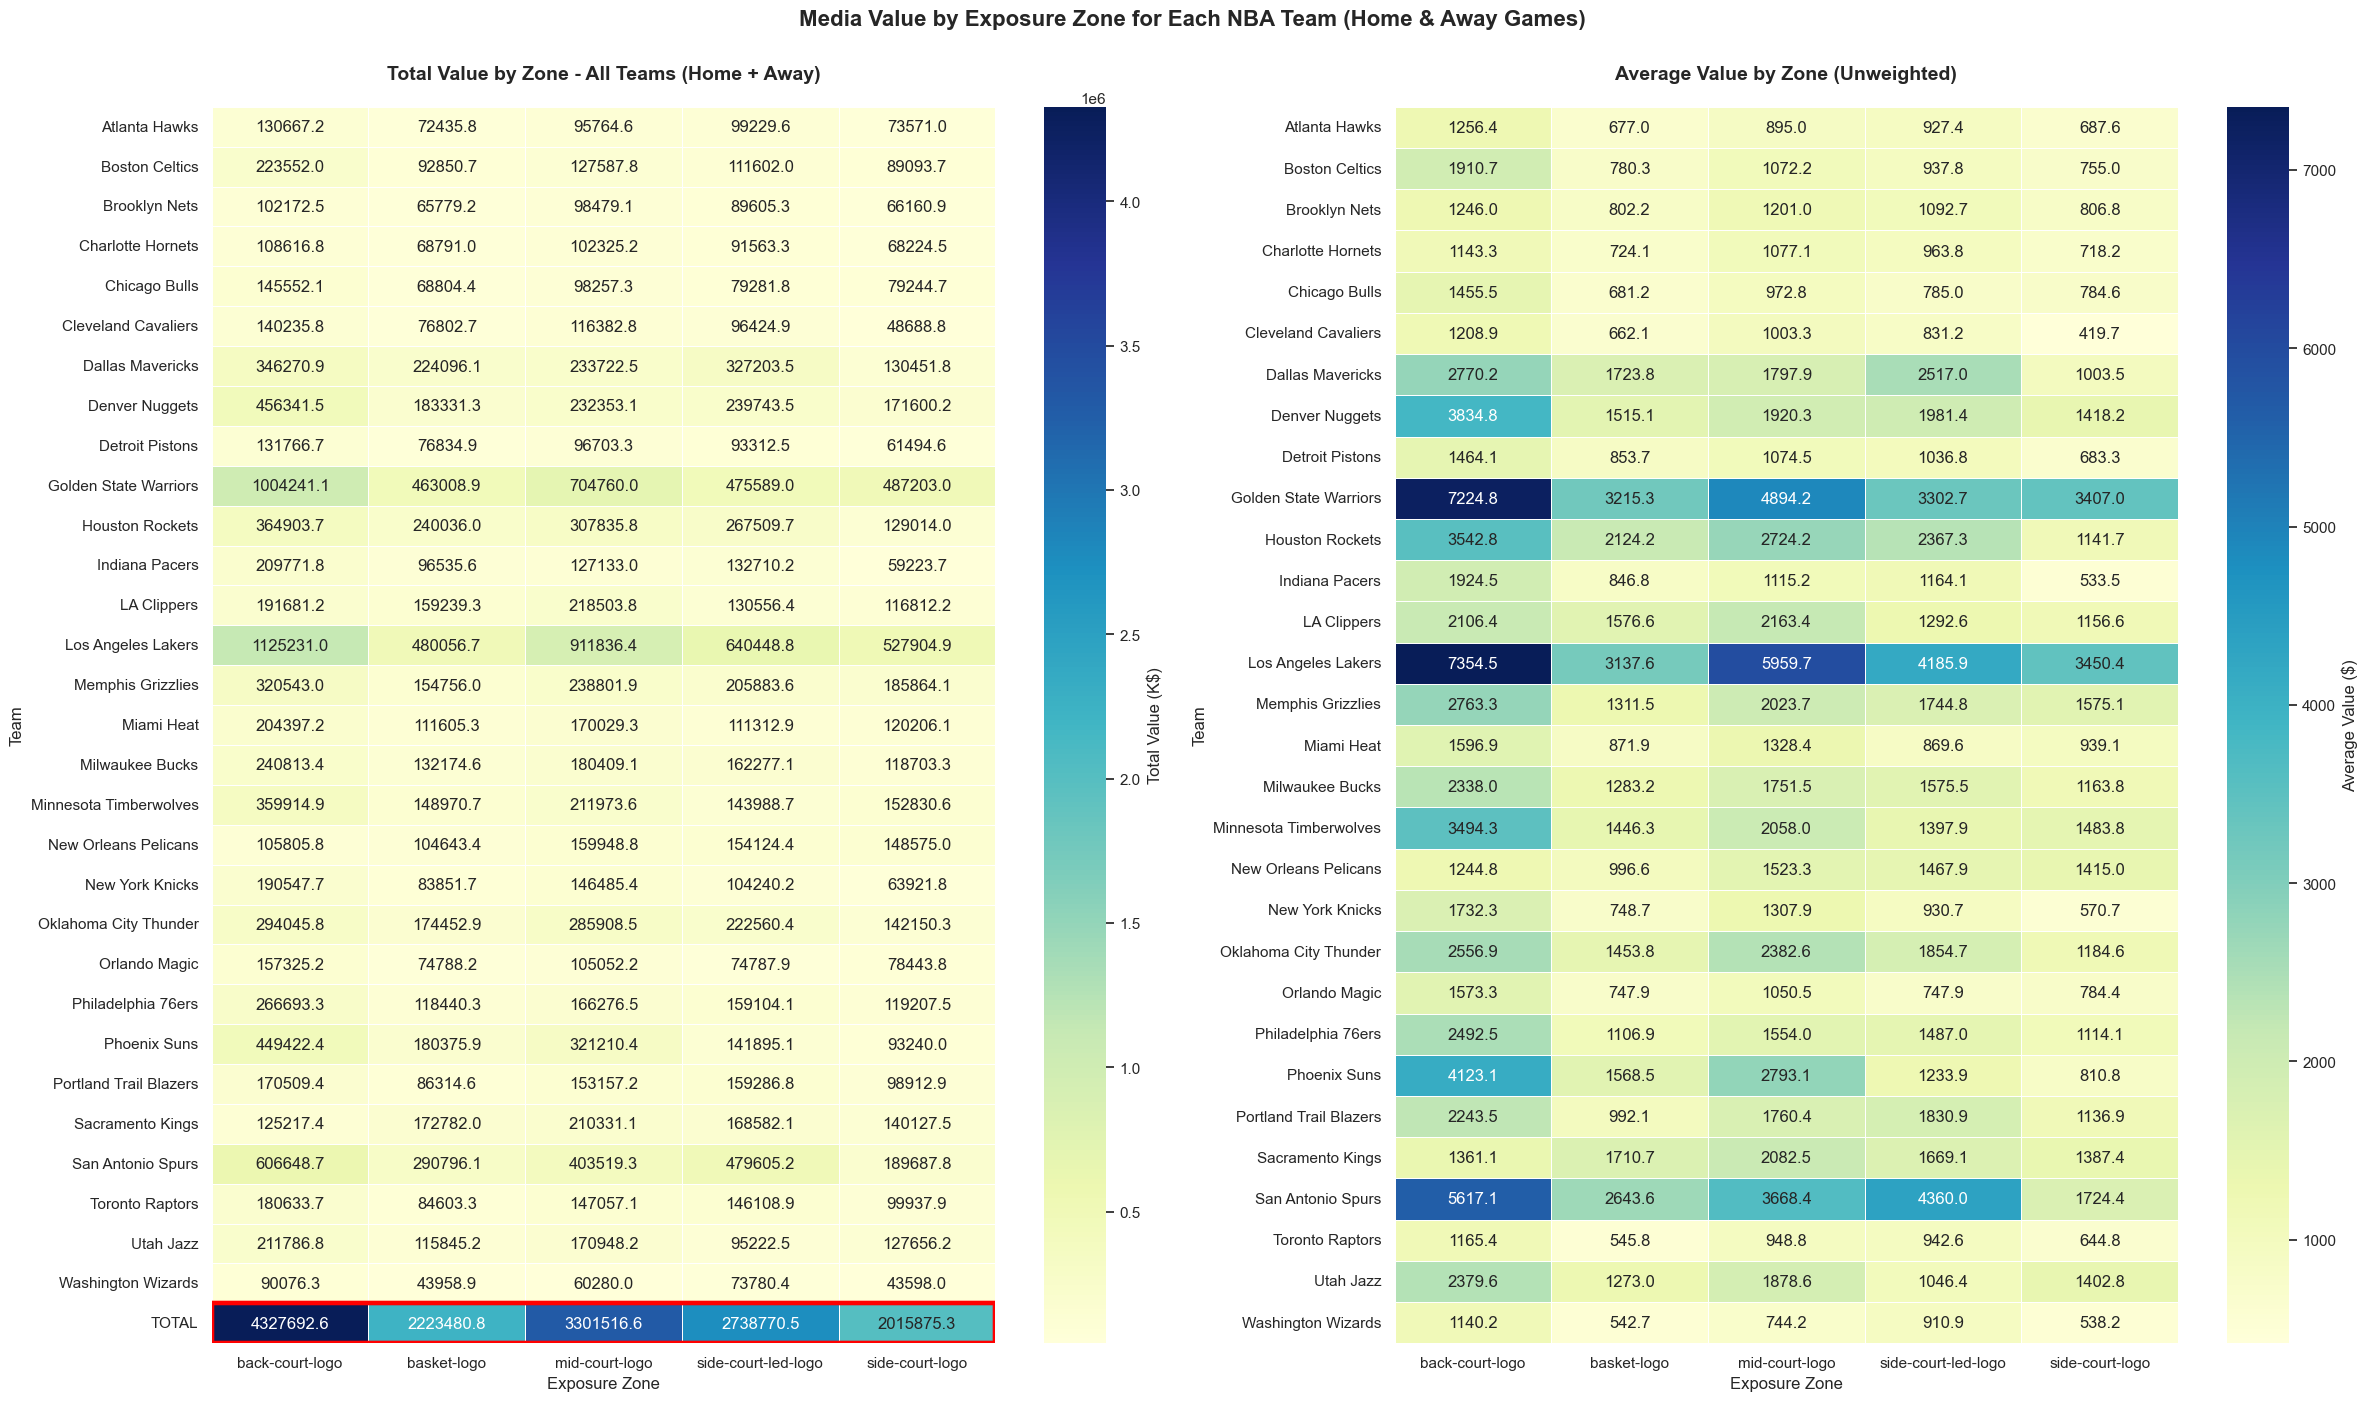

In [5]:
# =============================================================================
# VALUE BY ZONE FOR EACH TEAM (HOME OR AWAY)
# =============================================================================

# Create a team column that combines HOME and AWAY
df_team_zone = df.copy()

# For each row, we'll create two entries: one for home team, one for away team
df_home = df[['HOME_TEAM_NAME', 'exposure_zone', 'total_media_value', 'view_count']].copy()
df_home.columns = ['team', 'exposure_zone', 'total_media_value', 'view_count']

df_away = df[['AWAY_TEAM_NAME', 'exposure_zone', 'total_media_value', 'view_count']].copy()
df_away.columns = ['team', 'exposure_zone', 'total_media_value', 'view_count']

# Combine both
df_combined = pd.concat([df_home, df_away], ignore_index=True)

# =============================================================================
# CALCULATE METRICS
# =============================================================================

# 1. TOTAL VALUE by team and zone
df_total_value = df_combined.groupby(['team', 'exposure_zone'])['total_media_value'].sum()
df_heatmap_total = df_total_value.reset_index().pivot(
    index="team", 
    columns="exposure_zone", 
    values="total_media_value"
)

# Add TOTAL row (sum across all teams)
total_row = df_heatmap_total.sum(axis=0)/2
df_heatmap_total.loc['TOTAL'] = total_row

# 2. AVERAGE VALUE by team and zone (unweighted)
df_avg_value = df_combined.groupby(['team', 'exposure_zone'])['total_media_value'].mean()
df_heatmap_avg = df_avg_value.reset_index().pivot(
    index="team", 
    columns="exposure_zone", 
    values="total_media_value"
)

# Add AVERAGE row (mean across all teams)
#avg_row = df_heatmap_avg.mean(axis=0)
#df_heatmap_avg.loc['AVERAGE'] = avg_row

# =============================================================================
# VISUALIZATIONS
# =============================================================================

fig, axes = plt.subplots(1, 2, figsize=(24, 14))

# Left: Total Value
sns.heatmap(
    df_heatmap_total,  # Convert to thousands for readability
    cmap="YlGnBu",
    annot=True,
    fmt=".1f",
    linewidths=0.5,
    cbar_kws={"label": "Total Value (K$)"},
    ax=axes[0]
)
axes[0].set_title("Total Value by Zone - All Teams (Home + Away)", 
                     fontsize=14, fontweight='bold', pad=20)
axes[0].set_ylabel("Team", fontsize=12)
axes[0].set_xlabel("Exposure Zone", fontsize=12)

# Highlight the TOTAL row
total_row_idx = len(df_heatmap_total) - 1
for spine in ['top', 'bottom', 'left', 'right']:
    axes[0].add_patch(plt.Rectangle((0, total_row_idx), df_heatmap_total.shape[1], 1, 
                                     fill=False, edgecolor='red', lw=3))

# Right: Average Value
sns.heatmap(
    df_heatmap_avg,
    cmap="YlGnBu",
    annot=True,
    fmt=".1f",
    linewidths=0.5,
    cbar_kws={"label": "Average Value ($)"},
    ax=axes[1]
)
axes[1].set_title("Average Value by Zone (Unweighted)", 
                     fontsize=14, fontweight='bold', pad=20)
axes[1].set_ylabel("Team", fontsize=12)
axes[1].set_xlabel("Exposure Zone", fontsize=12)

# Highlight the AVERAGE row
avg_row_idx = len(df_heatmap_avg) - 1
plt.suptitle("Media Value by Exposure Zone for Each NBA Team (Home & Away Games)", 
             fontsize=16, fontweight='bold', y=1.00)
plt.tight_layout()
plt.show()

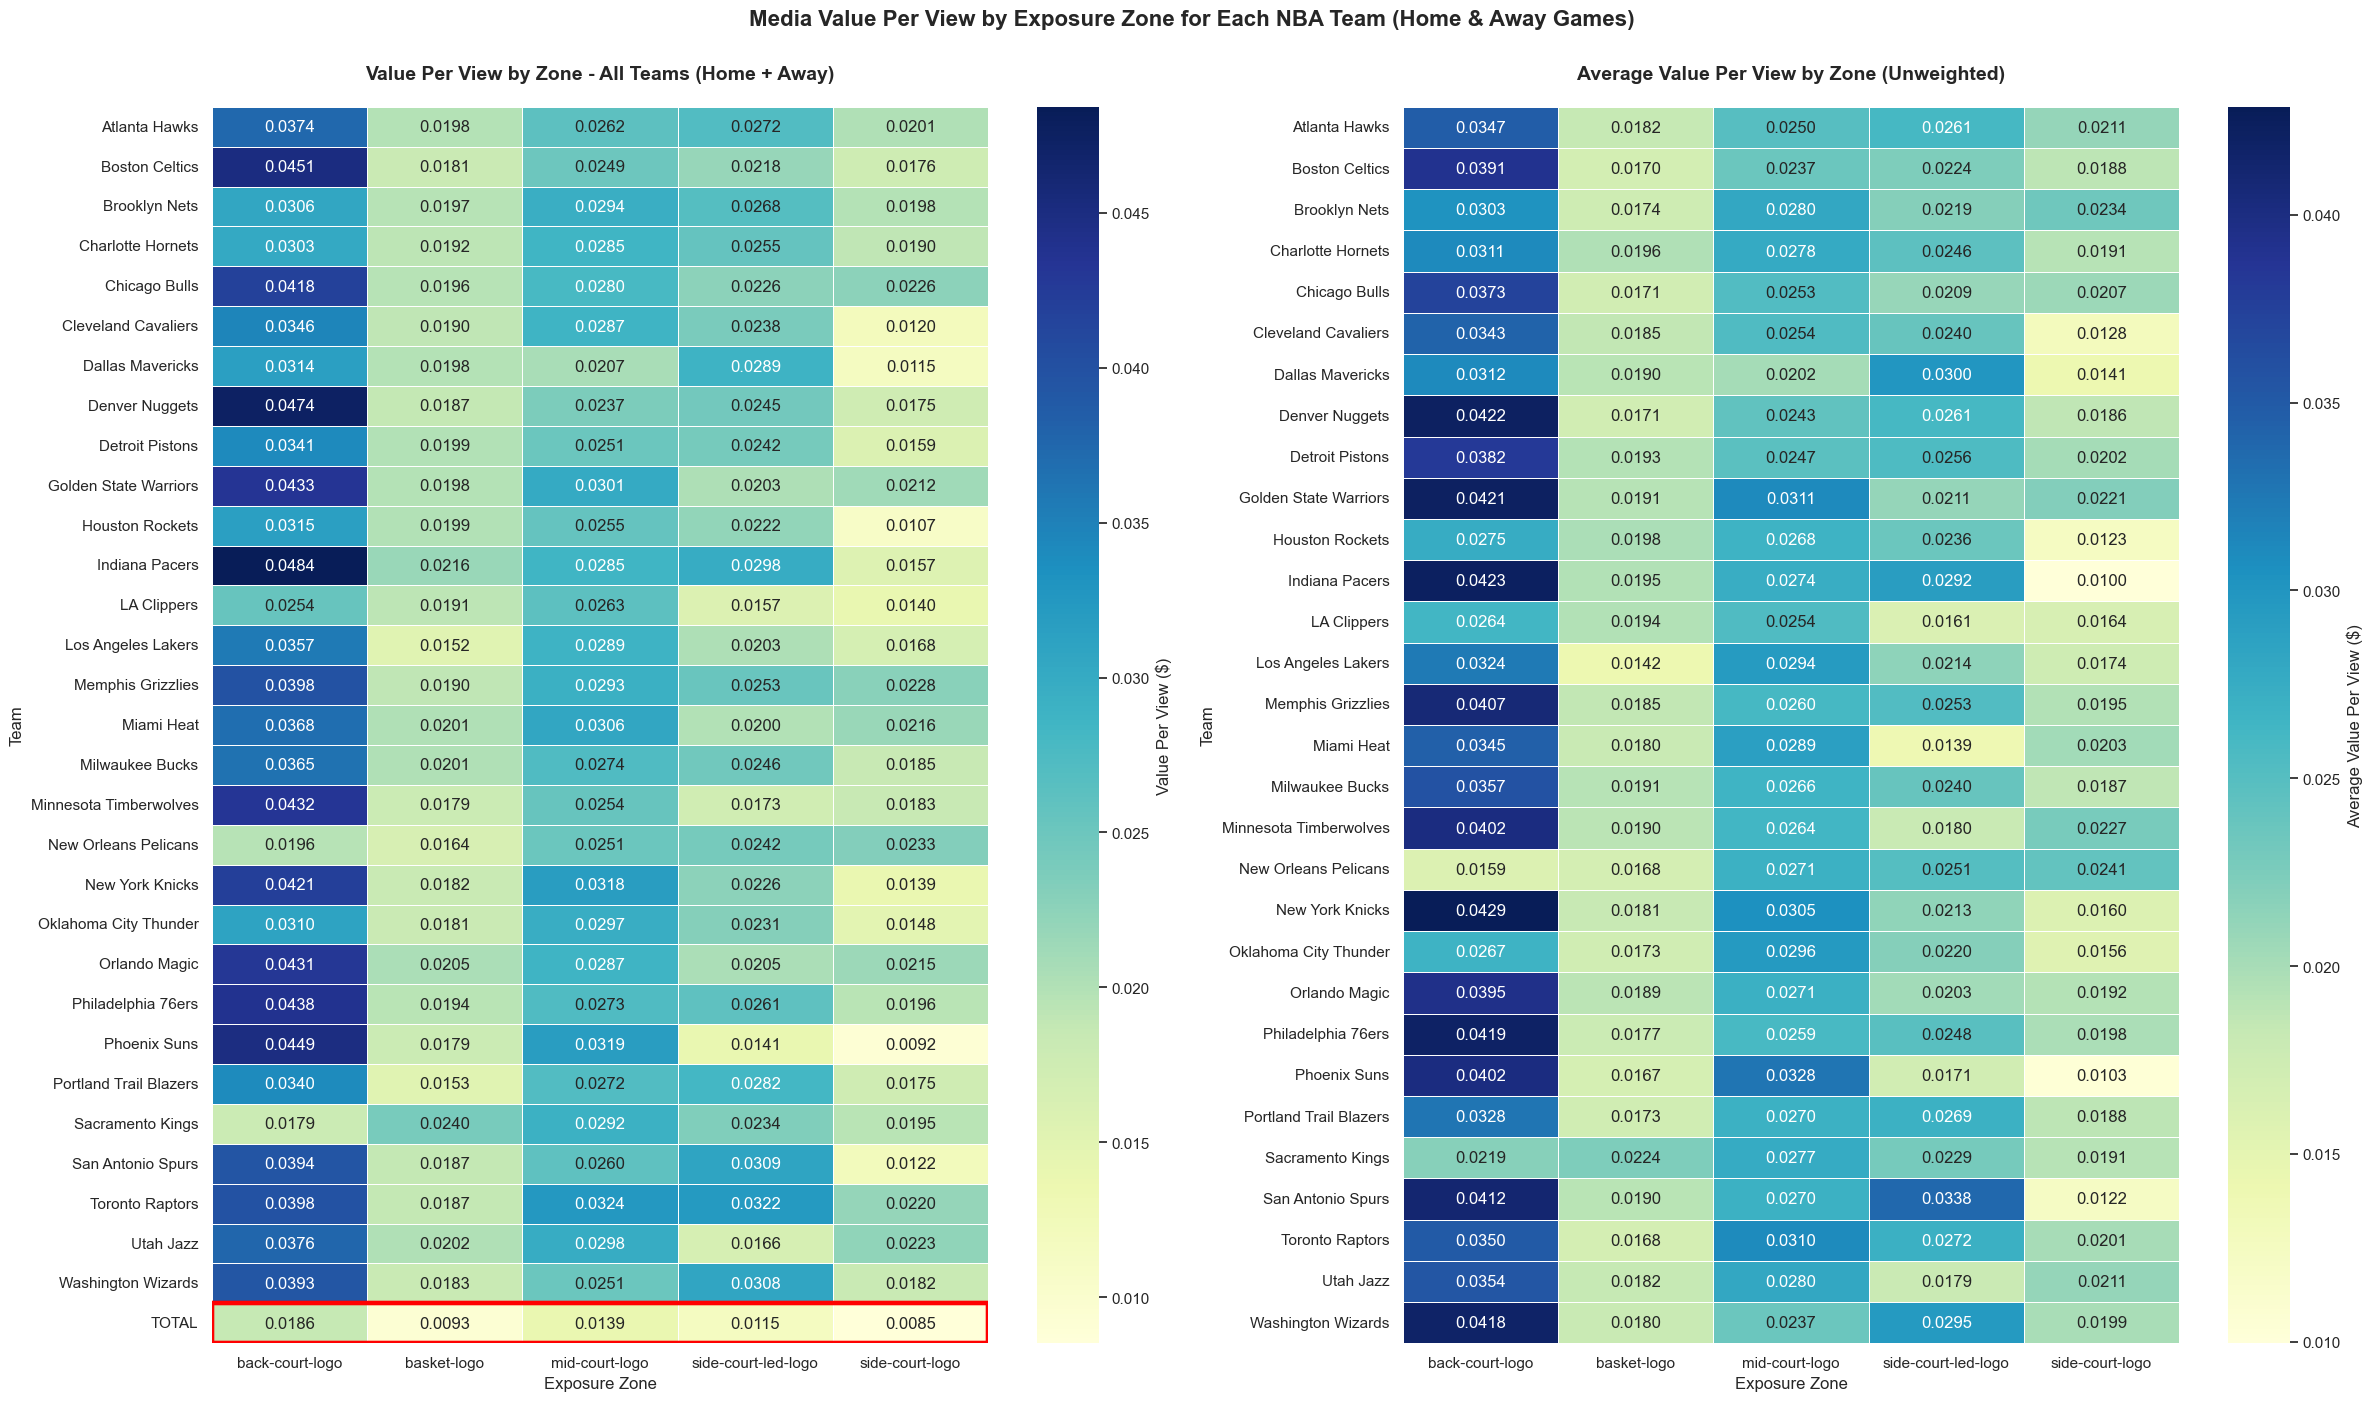

In [6]:
# =============================================================================
# VALUE PER VIEW BY ZONE FOR EACH TEAM (HOME OR AWAY)
# =============================================================================

# Create a team column that combines HOME and AWAY
df_team_zone = df.copy()

# For each row, we'll create two entries: one for home team, one for away team
df_home = df[['HOME_TEAM_NAME', 'exposure_zone', 'total_media_value', 'view_count']].copy()
df_home.columns = ['team', 'exposure_zone', 'total_media_value', 'view_count']

df_away = df[['AWAY_TEAM_NAME', 'exposure_zone', 'total_media_value', 'view_count']].copy()
df_away.columns = ['team', 'exposure_zone', 'total_media_value', 'view_count']

# Combine both
df_combined = pd.concat([df_home, df_away], ignore_index=True)

# =============================================================================
# CALCULATE METRICS - VALUE PER VIEW
# =============================================================================

# 1. TOTAL VALUE PER VIEW by team and zone (sum of value / sum of views)
df_grouped = df_combined.groupby(['team', 'exposure_zone']).agg({
    'total_media_value': 'sum',
    'view_count': 'sum'
}).reset_index()

df_grouped['value_per_view'] = df_grouped['total_media_value'] / df_grouped['view_count']

df_heatmap_total = df_grouped.pivot(
    index="team", 
    columns="exposure_zone", 
    values="value_per_view"
)

# Add TOTAL row (weighted average across all teams)
total_value = df_grouped.groupby('exposure_zone')['total_media_value'].sum()
total_views = df_grouped.groupby('exposure_zone')['view_count'].sum()
total_row = (total_value / total_views) / 2  # Divide by 2 since we counted each game twice
df_heatmap_total.loc['TOTAL'] = total_row

# 2. AVERAGE VALUE PER VIEW by team and zone (mean of individual value_per_view)
df_combined['value_per_view'] = df_combined['total_media_value'] / df_combined['view_count']
df_avg_value_per_view = df_combined.groupby(['team', 'exposure_zone'])['value_per_view'].mean()
df_heatmap_avg = df_avg_value_per_view.reset_index().pivot(
    index="team", 
    columns="exposure_zone", 
    values="value_per_view"
)

# =============================================================================
# VISUALIZATIONS
# =============================================================================

fig, axes = plt.subplots(1, 2, figsize=(24, 14))

# Left: Total Value Per View
sns.heatmap(
    df_heatmap_total,
    cmap="YlGnBu",
    annot=True,
    fmt=".4f",
    linewidths=0.5,
    cbar_kws={"label": "Value Per View ($)"},
    ax=axes[0]
)
axes[0].set_title("Value Per View by Zone - All Teams (Home + Away)", 
                     fontsize=14, fontweight='bold', pad=20)
axes[0].set_ylabel("Team", fontsize=12)
axes[0].set_xlabel("Exposure Zone", fontsize=12)

# Highlight the TOTAL row
total_row_idx = len(df_heatmap_total) - 1
for spine in ['top', 'bottom', 'left', 'right']:
    axes[0].add_patch(plt.Rectangle((0, total_row_idx), df_heatmap_total.shape[1], 1, 
                                     fill=False, edgecolor='red', lw=3))

# Right: Average Value Per View
sns.heatmap(
    df_heatmap_avg,
    cmap="YlGnBu",
    annot=True,
    fmt=".4f",
    linewidths=0.5,
    cbar_kws={"label": "Average Value Per View ($)"},
    ax=axes[1]
)
axes[1].set_title("Average Value Per View by Zone (Unweighted)", 
                     fontsize=14, fontweight='bold', pad=20)
axes[1].set_ylabel("Team", fontsize=12)
axes[1].set_xlabel("Exposure Zone", fontsize=12)

plt.suptitle("Media Value Per View by Exposure Zone for Each NBA Team (Home & Away Games)", 
             fontsize=16, fontweight='bold', y=1.00)
plt.tight_layout()
plt.show()

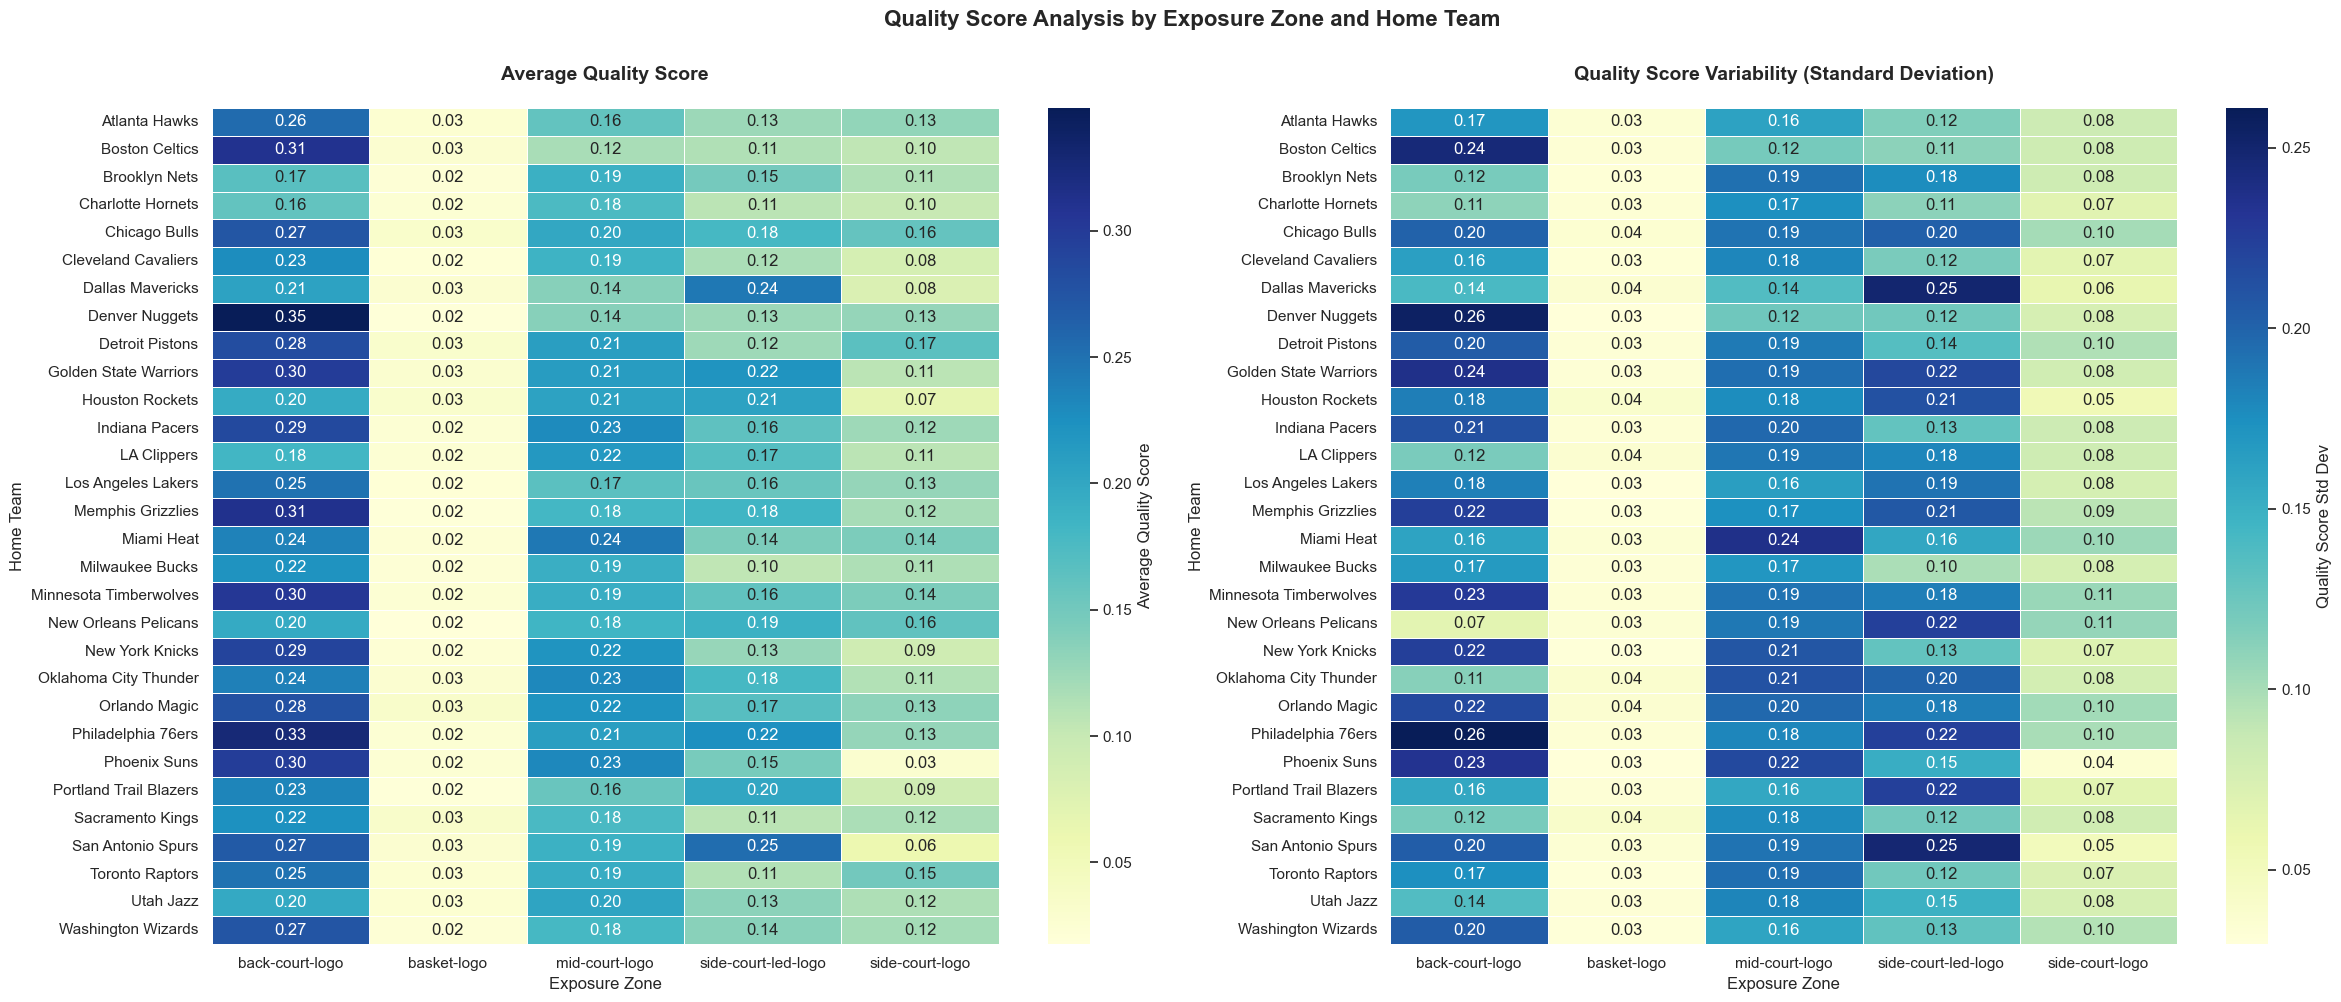

In [7]:
# =============================================================================
# QUALITY SCORE HEATMAPS BY HOME TEAM
# =============================================================================

# 1. Calculate average quality score by home team and zone
df_avg_by_team = df.groupby(['HOME_TEAM_NAME', 'exposure_zone'])['qi_score_avg'].mean()
df_avg = df_avg_by_team.reset_index().pivot(
    index="HOME_TEAM_NAME", 
    columns="exposure_zone", 
    values="qi_score_avg"
)

# 2. Calculate quality score standard deviation by home team and zone
df_std_by_team = df.groupby(['HOME_TEAM_NAME', 'exposure_zone'])['qi_score_std'].mean()
df_std = df_std_by_team.reset_index().pivot(
    index="HOME_TEAM_NAME", 
    columns="exposure_zone", 
    values="qi_score_std"
)

# 3. Side-by-side visualization
fig, axes = plt.subplots(1, 2, figsize=(24, 10))

# Heatmap: Average Quality Score
sns.heatmap(
    df_avg,
    cmap="YlGnBu",
    annot=True,
    fmt=".2f",
    linewidths=0.5,
    cbar_kws={"label": "Average Quality Score"},
    ax=axes[0]
)
axes[0].set_title("Average Quality Score", fontsize=14, fontweight='bold', pad=20)
axes[0].set_ylabel("Home Team")
axes[0].set_xlabel("Exposure Zone")

# Heatmap: Quality Score Variability
sns.heatmap(
    df_std,
    cmap="YlGnBu",
    annot=True,
    fmt=".2f",
    linewidths=0.5,
    cbar_kws={"label": "Quality Score Std Dev"},
    ax=axes[1]
)
axes[1].set_title("Quality Score Variability (Standard Deviation)", fontsize=14, fontweight='bold', pad=20)
axes[1].set_ylabel("Home Team")
axes[1].set_xlabel("Exposure Zone")

plt.suptitle("Quality Score Analysis by Exposure Zone and Home Team", 
             fontsize=16, fontweight='bold', y=1.00)
plt.tight_layout()
plt.show()

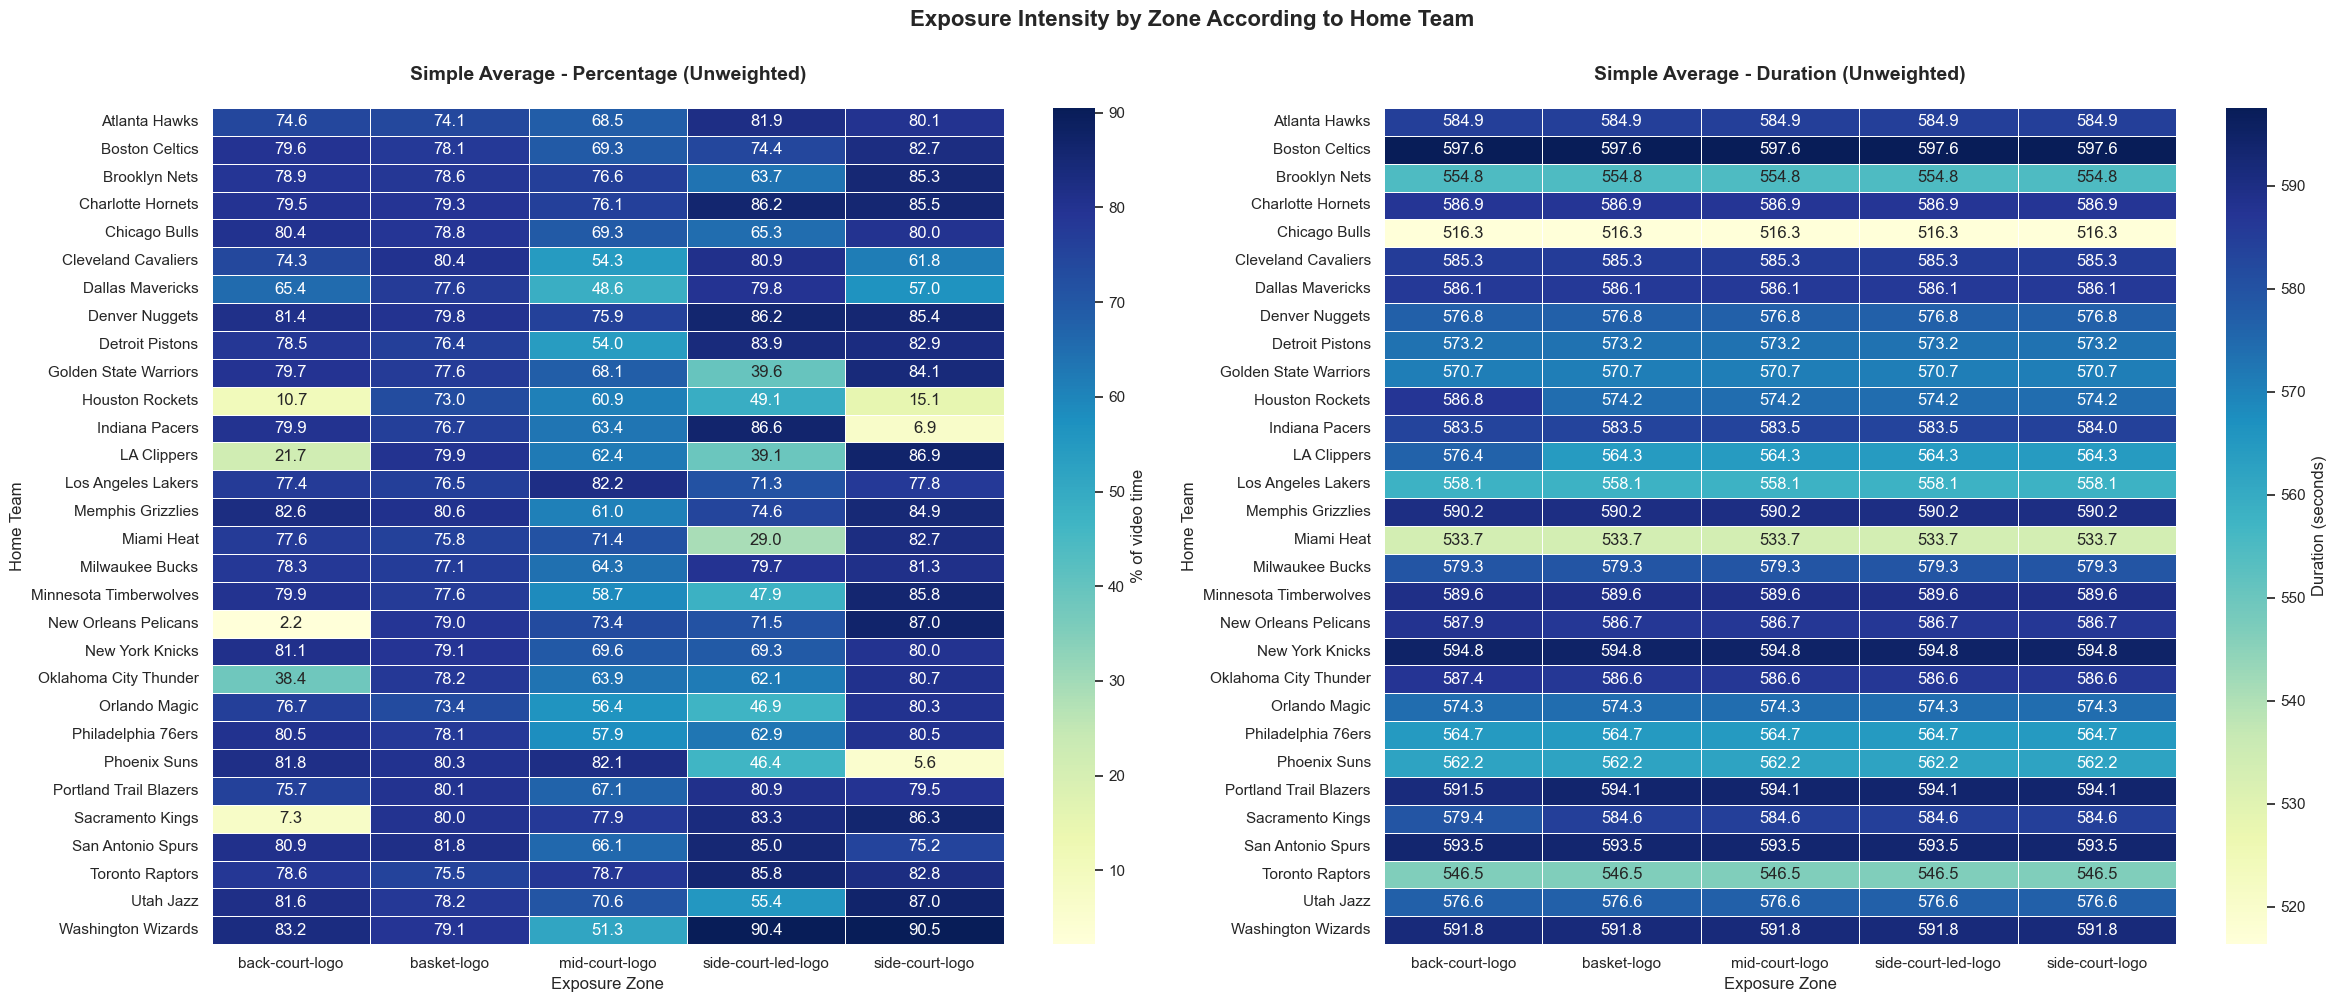

In [8]:
# =============================================================================
# EXPOSURE ANALYSIS: PERCENTAGE AND DURATION
# =============================================================================

df['percentage_exposition'] = (df['exposure_seconds'] / df['duration']) * 100

# 1. Calculate UNWEIGHTED average (percentage)
df_unweighted_pct = df.groupby(['HOME_TEAM_NAME', 'exposure_zone'])['percentage_exposition'].mean()
df_heatmap_unweighted_pct = df_unweighted_pct.reset_index().pivot(
    index="HOME_TEAM_NAME", 
    columns="exposure_zone", 
    values="percentage_exposition"
)

# 2. Calculate UNWEIGHTED average (duration)
df_unweighted_dur = df.groupby(['HOME_TEAM_NAME', 'exposure_zone'])['duration'].mean()
df_heatmap_unweighted_dur = df_unweighted_dur.reset_index().pivot(
    index="HOME_TEAM_NAME", 
    columns="exposure_zone", 
    values="duration"
)

# 3. Visualization - 2x1 Grid
fig, axes = plt.subplots(1, 2, figsize=(24, 10))

# Top: Unweighted Percentage
sns.heatmap(
    df_heatmap_unweighted_pct,
    cmap="YlGnBu",
    annot=True,
    fmt=".1f",
    linewidths=0.5,
    cbar_kws={"label": "% of video time"},
    ax=axes[0]
)
axes[0].set_title("Simple Average - Percentage (Unweighted)", fontsize=14, fontweight='bold', pad=20)
axes[0].set_ylabel("Home Team", fontsize=12)
axes[0].set_xlabel("Exposure Zone", fontsize=12)

# Bottom: Unweighted Duration
sns.heatmap(
    df_heatmap_unweighted_dur,
    cmap="YlGnBu",
    annot=True,
    fmt=".1f",
    linewidths=0.5,
    cbar_kws={"label": "Duration (seconds)"},
    ax=axes[1]
)
axes[1].set_title("Simple Average - Duration (Unweighted)", fontsize=14, fontweight='bold', pad=20)
axes[1].set_ylabel("Home Team", fontsize=12)
axes[1].set_xlabel("Exposure Zone", fontsize=12)

plt.suptitle("Exposure Intensity by Zone According to Home Team", 
             fontsize=16, fontweight='bold', y=1.00)
plt.tight_layout()
plt.show()